In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from datetime import datetime

In [2]:
df = pd.read_csv("marketing_data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,16-06-2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,15-06-2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,13-05-2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,11-05-2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,08-04-2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

C:\Users\Shreya Ranjan\AppData\Local\Temp\ipykernel_14496\177162232.py:1: UserWarning: Parsing '16-06-2014' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
C:\Users\Shreya Ranjan\AppData\Local\Temp\ipykernel_14496\177162232.py:1: UserWarning: Parsing '15-06-2014' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
C:\Users\Shreya Ranjan\AppData\Local\Temp\ipykernel_14496\177162232.py:1: UserWarning: Parsing '13-05-2014' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
C:\Users\Shreya Ranjan\AppData\Local\Temp\ipykernel_14496\177162232.py:1: UserWarning: Parsing '17-03-2014' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  df

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [13]:
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Income']).copy()

In [14]:
df['Age'] = 2026 - df['Year_Birth']

In [15]:
#Total Spending Column

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [16]:
#Total Purchase Column

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

### Campaign Conversion Analysis

In [17]:
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5'
]

In [18]:
conversion_rates = df[campaign_cols].mean() * 100

print("Campaign Conversion Rates (%)")
print(conversion_rates)

Campaign Conversion Rates (%)
AcceptedCmp1    6.407942
AcceptedCmp2    1.353791
AcceptedCmp3    7.355596
AcceptedCmp4    7.400722
AcceptedCmp5    7.310469
dtype: float64


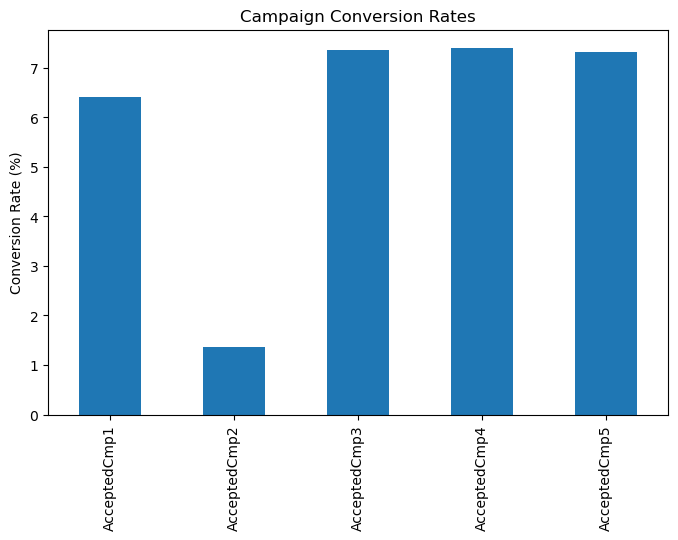

In [19]:
plt.figure(figsize=(8,5))

conversion_rates.plot(kind='bar')

plt.title("Campaign Conversion Rates")
plt.ylabel("Conversion Rate (%)")

plt.show()

### A/B Testing using Z-Test

In [21]:
best_campaign = conversion_rates.idxmax()
worst_campaign = conversion_rates.idxmin()

print("Best Campaign:", best_campaign)
print("Worst Campaign:", worst_campaign)

Best Campaign: AcceptedCmp4
Worst Campaign: AcceptedCmp2


In [22]:
successes = [
    df[best_campaign].sum(),
    df[worst_campaign].sum()
]

totals = [
    df[best_campaign].count(),
    df[worst_campaign].count()
]

z_stat, p_value = proportions_ztest(successes, totals)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: 9.838374115219558
P Value: 7.694421616997799e-23


In [23]:
if p_value < 0.05:
    print("The difference between campaigns is statistically significant.")
else:
    print("No statistically significant difference between campaigns.")

The difference between campaigns is statistically significant.


### RFM Analysis (Customer Segmentation)

In [24]:
#Recency

today = datetime(2026,1,1)

df['Recency_days'] = (today - df['Dt_Customer']).dt.days

In [27]:
#Frequency

df['Frequency'] = df['Total_Purchases']

In [28]:
#Monetary

df['Monetary'] = df['Total_Spending']

In [29]:
#Scoring

df['R_Score'] = pd.qcut(df['Recency_days'],4,labels=[4,3,2,1])

In [30]:
df['F_Score'] = pd.qcut(df['Frequency'].rank(method='first'),4,labels=[1,2,3,4])

In [31]:
df['M_Score'] = pd.qcut(df['Monetary'],4,labels=[1,2,3,4])

In [35]:
df['Total_RFM_Score'] = (
    df['R_Score'].astype(int) + 
    df['F_Score'].astype(int) + 
    df['M_Score'].astype(int)
)

### Customer Segmentation

In [36]:
def segment_customer_refined(row):
    score = row['Total_RFM_Score']
    recency = int(row['R_Score'])
    
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        if recency >= 3:
            return 'Potential Loyalists'
        else:
            return 'At Risk'
    elif score >= 4:
        return 'Promising/New'
    else:
        return 'Hibernating/Lost'

df['Customer_Segment'] = df.apply(segment_customer_refined, axis=1)

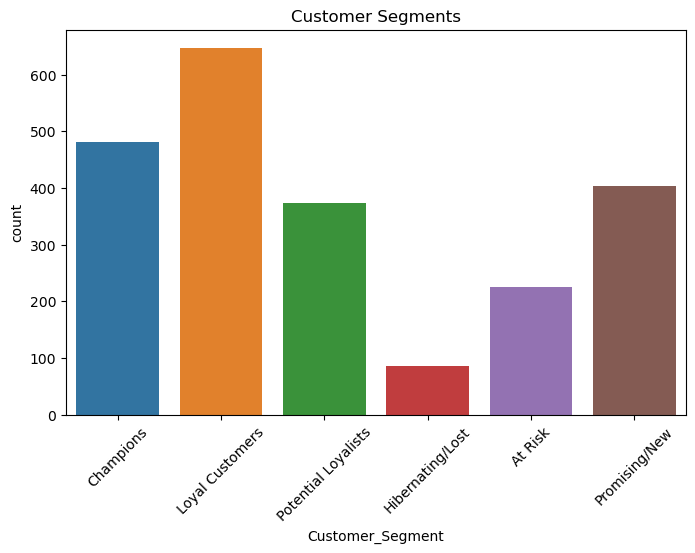

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x='Customer_Segment', data=df)

plt.xticks(rotation=45)

plt.title("Customer Segments")

plt.show()

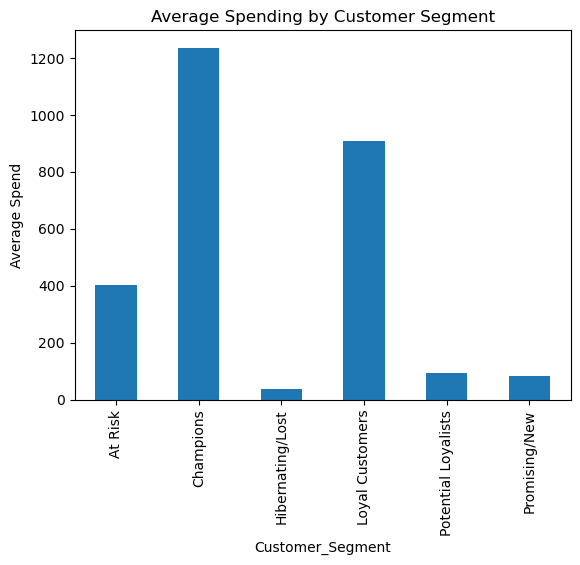

In [39]:
#Average Spending by Customer Segment

segment_spending = df.groupby('Customer_Segment')['Monetary'].mean()

segment_spending.plot(kind='bar')

plt.title("Average Spending by Customer Segment")

plt.ylabel("Average Spend")

plt.show()

In [40]:
df.to_csv("marketing_campaign_cleaned.csv", index=False)